In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
os.makedirs("plots", exist_ok=True)
import sys
sys.path.append("../")
from cumulant_analyzer import calculate_cumulants, to_numpy, shuffle_tokens
%matplotlib inline

from transformer_lens import HookedTransformer, HookedTransformerConfig
import torch.nn.functional as F

# from tqdm import tqdm

## Mess3 Process

In [2]:
class Mess3Process:
    def __init__(self, x=0.05, alpha=0.85, device='cuda'):
        self.x = x
        self.alpha = alpha
        self.device = device
        self.T = self.get_transition_matrix()
        # For a generic process, replace the prior with the stationary distribution
        self.prior = torch.ones(3, device = device) / 3
        

    def get_transition_matrix(self):
        x = self.x
        alpha = self.alpha
        T = torch.zeros((3, 3, 3))  # Shape: [source, target, token]
        for source in range(3):  # iterating over source hidden states
            for target in range(3):  # iterating over target hidden states
                for token in range(3):  # iterating over tokens
                    # p(source->target)
                    p_source_target = 1 - 2 * x if source == target else x
                    # p(token | target)
                    p_token = alpha if token == target else (1 - alpha) / 2
                    T[source, target, token] = p_source_target * p_token
        return T.to(self.device)

    def find_next_state(self, current_states):
        """
        current_states: Tensor of shape (B,) where each entry is an integer state (0, 1, or 2)
        Returns:
            next_states: Tensor of shape (B,)
            tokens: Tensor of shape (B,)
        """
        B = current_states.shape[0]
        # For each state in the batch, select the [target x token] matrix.
        probs = self.T[current_states]  # shape: (B, 3, 3)
        probs = probs.view(B, -1)       # flatten each [3, 3] matrix to a vector of size 9 per batch element
        # Sample an index for each element in the batch.
        idx = torch.multinomial(probs, num_samples=1).squeeze(1)  # shape: (B,)
        next_states = idx // 3
        tokens = idx % 3
        return next_states, tokens

    def generate_sequences(self, length=10, batch_size=32):
        """
        Generates a batch of sequences.
        Returns:
            sequences: Tensor of shape (B, L) containing tokens.
            states_seq: Tensor of shape (B, L) containing the next hidden states.
        """
        sequences = []   # to collect tokens from each time step (each: shape (B,))
        states_seq = []  # to collect next states from each time step (each: shape (B,))
        # Initialize a batch of starting states.
        current_states = torch.randint(0, 3, (batch_size,))
        for _ in range(length):
            next_states, tokens = self.find_next_state(current_states)
            sequences.append(tokens)      # tokens: shape (B,)
            states_seq.append(next_states)
            current_states = next_states  # update states for the next step
        # Stack along the time dimension to yield tensors of shape (B, L)
        sequences = torch.stack(sequences, dim=1)
        states_seq = torch.stack(states_seq, dim=1)
        return sequences, states_seq

    def update_belief_state(self, current_belief, tokens):
        """
        current_belief: Tensor of shape (B, 3), representing the belief distribution for each sample.
        tokens: Tensor of shape (B,), each an integer token.
        
        For each sample i, the update is:
            next_belief[i] = current_belief[i] @ T[:, :, tokens[i]]
        Uses vectorized operations with torch.bmm.
        """
        # Rearrange T so that tokens come first: shape (3, 3, 3) -> (token, source, target)
        T_batch = self.T.permute(2, 0, 1)[tokens]  # shape: (B, 3, 3)
        next_belief = torch.bmm(current_belief.unsqueeze(1), T_batch).squeeze(1)  # shape: (B, 3)
        # Normalize each belief vector
        next_belief = next_belief / next_belief.sum(dim=1, keepdim=True)
        return next_belief

    def find_belief_states(self, sequences):
        """
        sequences: Tensor of shape (B, L) where each row is a sequence of tokens.
        Returns: belief_states, a tensor of shape (B, L+1, 3), where the initial belief is the prior.
        """
        B, L = sequences.shape
        current_belief = self.prior.unsqueeze(0).expand(B, -1)  # shape: (B, 3)
        belief_states = [current_belief]
        for t in range(L):
            current_belief = self.update_belief_state(current_belief, sequences[:, t])
            belief_states.append(current_belief)
        # Stack along the time dimension: (B, L+1, 3)
        belief_states = torch.stack(belief_states, dim=1)
        return belief_states

    def find_belief_loss(self, sequences, include_start = True):
        """
        sequences: Tensor of shape (B, L) containing tokens.
        Computes the belief loss averaged over both batch and time dimensions.
        The prediction for the next state is obtained by multiplying the current belief state
        with the transition matrix summed over the target dimension.
        """
        B, L = sequences.shape
        belief_states = self.find_belief_states(sequences)  # shape: (B, L+1, 3)
        # Sum T over the target dimension: resulting shape (3, 3)
        transition_matrix = self.T.sum(dim=-2)  
        # For each batch sample and time step, compute the predicted next state distribution:
        predicted = torch.bmm(belief_states[:, :-1, :], transition_matrix.expand(B, -1, -1))  # shape: (B, L, 3)
        # print(predicted)
        # Gather the probability of the actual observed token at each time step.
        token_probs = predicted.gather(dim=2, index=sequences.unsqueeze(-1)).squeeze(-1)  # shape: (B, L)
        empirical_loss = -torch.log(token_probs)
        start_index = 1 - int(include_start)
        return empirical_loss[:, start_index:]

## Cumulants at different lengths

In [3]:
# Your existing data collection code
ans = []
lengths = np.logspace(1, 3.5, 20).astype(int)  # 10^1 to 10^3 with 10 points
# print("Lengths:", lengths)

for length in lengths:
    mess3 = Mess3Process()
    tokens, states = mess3.generate_sequences(batch_size=500, length=length)
    B, L = tokens.shape
    belief_states = mess3.find_belief_states(tokens)  # shape: (B, L+1, 3)
    # Sum T over the target dimension: resulting shape (3, 3)
    transition_matrix = mess3.T.sum(dim=-2)  
    # For each batch sample and time step, compute the predicted next state distribution:
    predicted = torch.bmm(belief_states[:, :-1, :], transition_matrix.expand(B, -1, -1))  # shape: (B, L, 3)
    stats = calculate_cumulants(torch.log(predicted), predicted)
    ans.append(stats['avg_normalized_cumulants'].cpu().numpy().mean(axis=0))


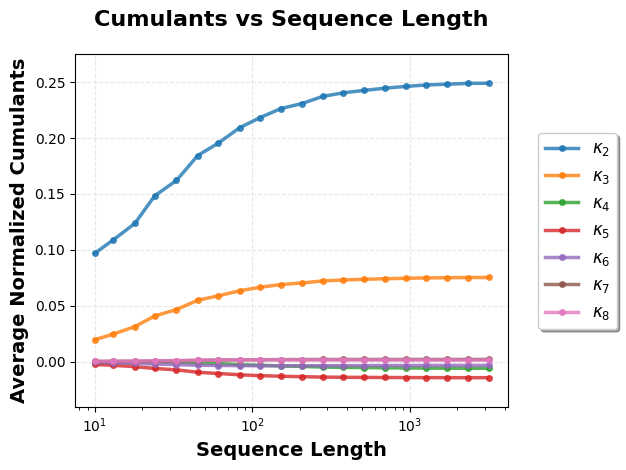

In [4]:
ans = np.array(ans)

# Define colors for each cumulant order
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# Create a more polished plot
# plt.figure(figsize=(10, 7))

# Plot each cumulant order as a separate line
for i in range(ans.shape[1]):  # Iterate over cumulant orders
    plt.plot(lengths, ans[:, i], 
             marker = '.',
             linewidth=2.5, 
             markersize=8, 
             color=colors[i % len(colors)],
             alpha=0.8,
             label=f'$\\kappa_{{{i+2}}}$')


plt.xscale('log')

# Styling
plt.xlabel('Sequence Length', fontsize=14, fontweight='bold')
plt.ylabel('Average Normalized Cumulants', fontsize=14, fontweight='bold')
plt.title('Cumulants vs Sequence Length', fontsize=16, fontweight='bold', pad=20)

# Grid and layout
plt.grid(True, alpha=0.3, linestyle='--')
# plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, ncol=2)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, 
          bbox_to_anchor=(1.05, 0.8), loc='upper left')
plt.tight_layout()
             
# Add some padding to the axes
plt.margins(x=0.05, y=0.1)

plt.show()

## Cumulants across training

In [6]:
DEVICE = "cuda"  
SEQ_LEN = 100

@torch.no_grad()
def compute_validation_loss(model, val_input, val_target):
    model.eval()
    logits = model(val_input)
    loss = F.cross_entropy(
        logits.reshape(-1, config.d_vocab),
        val_target.reshape(-1)
    )
    model.train()
    return loss.item()

def prepare_data(BATCH_SIZE, SEQ_LEN, device = DEVICE):
    mess3 = Mess3Process()
    sequences, _ = mess3.generate_sequences(SEQ_LEN, BATCH_SIZE)
    sequences = sequences.to(device)
    input_seqs = sequences[:, :-1]
    target_seqs = sequences[:, 1:]
    return sequences, input_seqs, target_seqs


# Preparing validation dataset
VAL_BATCH_SIZE = 1000
val_sequences, val_input_seqs, val_target_seqs = prepare_data(VAL_BATCH_SIZE, SEQ_LEN, device = DEVICE)
belief_val_loss = Mess3Process().find_belief_loss(val_sequences, include_start=False).mean().item()

In [7]:
config = HookedTransformerConfig(
            d_model=64,
            d_head=16,
            n_layers=3,
            n_ctx=SEQ_LEN,
            n_heads=4,
            d_mlp=256,
            d_vocab=3,
            device="cuda",
            act_fn="relu",
        )
model = HookedTransformer(config)

In [8]:
BATCH_SIZE = 128
NUM_STEPS = 1001    # adjust the number of training steps as needed
# VALIDA_AFTER = 100   # frequency of logging training progress

# Initialize optimizer for your model.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_log = {'train': [], 'validation':[], 'cumulants': []}
figs = []  # a list to store your figures
PLOT_AFTER = 50
for step in tqdm(range(NUM_STEPS)):
    train_sequences, input_tensor, target_tensor = prepare_data(BATCH_SIZE, SEQ_LEN, device = DEVICE)

    # --- Forward Pass ---
    logits = model(input_tensor)

    # --- Loss Calculation ---
    loss = F.cross_entropy(
        logits.reshape(-1, config.d_vocab),
        target_tensor.reshape(-1)
    )

    # --- Backward Pass and Optimization ---
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Log training loss.
    loss_log['train'].append(loss.item())

    if step% PLOT_AFTER == 0:
        model.eval()
        val_loss = compute_validation_loss(model, val_input_seqs, val_target_seqs)
        loss_log['validation'].append(val_loss)
        val_logits = model(val_input_seqs)
        loss_log['cumulants'].append(calculate_cumulants(val_logits, torch.softmax(val_logits, dim=-1)))
        model.train()
        
            

print("Training complete.")

  0%|          | 0/1001 [00:00<?, ?it/s]

Training complete.


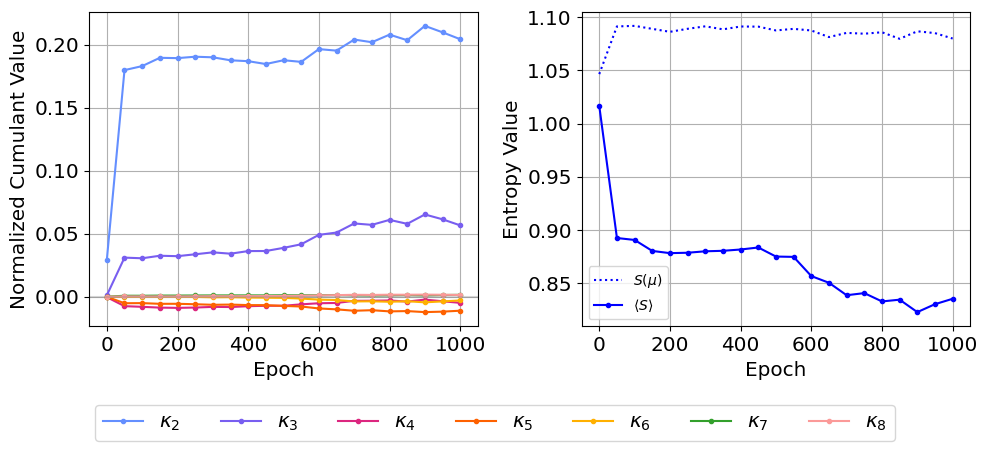

In [14]:
steps = np.arange(0, NUM_STEPS, PLOT_AFTER)
import matplotlib.colors as mcolors
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
# plot_stats(stats, axes[0], title = None, xarr = np.arange(len(steps)), xlabel = "Epochs")
ax = axes[0]
axes[0].set_ylabel("Normalized Cumulant Value", fontsize = "x-large")

hex6 = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000', '#33A02C', '#FB9A99']
colors6 = [mcolors.to_rgb(i) for i in hex6]

# Set color cycle for the axis
ax.set_prop_cycle('color', colors6)

# Get cumulants data
prompt_idx = 1

cumulants = np.array([item['avg_normalized_cumulants'][prompt_idx].cpu().numpy() for item in loss_log['cumulants']])


# Plot each cumulant
for idx in range(7):
    xarr = np.linspace(0, 1, cumulants.shape[0])
    ax.plot(xarr,
        cumulants.T[idx],
        marker='.',
        label=f"$\\kappa_{{{idx+2}}}$"
    )

# Set title and add grid
# if title is not None: ax.set_title(title, fontsize = "x-large")
ax.grid(True)
xlabel = 'Epochs'
ax.set_xlabel(xlabel, fontsize = "x-large")
ax.set_ylabel('Normalized Cumulant Value', fontsize = "x-large")

# Add y=0 reference line
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

ax.tick_params(which='both', labelsize="x-large")



ax = axes[1]
ax.plot(xarr, [item['entropy_com'][prompt_idx].cpu().numpy() for item in loss_log['cumulants']], c = 'blue', linestyle = 'dotted',label = "$S(\mu)$")
ax.plot(xarr, [item['avg_entropy'][prompt_idx].cpu().numpy() for item in loss_log['cumulants']], marker = '.', c = 'blue', label = "$\langle S \\rangle$")
ax.grid(True)
ax.set_xlabel('Epochs')
ax.legend()

ax.set_ylabel("Entropy Value", fontsize = "x-large")
n_points = cumulants.shape[0]
for ax in axes:
    ax.set_xlabel("Epoch", fontsize = "x-large")
    ax.tick_params(which='both', labelsize="x-large")
    if len(steps) == n_points:
        tick_indices = range(0, n_points, max(1, n_points//5))  # Show ~5 ticks
        ax.set_xticks([xarr[i] for i in tick_indices])
        ax.set_xticklabels([steps[i] for i in tick_indices])
    xticks = [idx for idx in range(0, 9, 2)]
    # ax.set_xticks(xticks, steps[xticks])

handles_psim, labels_psim = axes[0].get_legend_handles_labels()
fig.legend(handles_psim, labels_psim, loc='upper center', bbox_to_anchor=(0.5, -0.0), ncol = 7,  fontsize = "x-large")
plt.tight_layout()
# plt.savefig(f'plots/training.png', bbox_inches='tight')
plt.show()